In [40]:
import pandas as pd
import numpy as np

# run this command in terminal first: pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# run this command in terminal first: pip install pandas scikit-learn xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.cluster import KMeans

# run this command in terminal first: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# from P'Pun's code 
# run this command in terminal first: pip install umap-learn
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from umap import UMAP
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score


In [41]:
df = pd.read_csv('cleaned_yrbs_data.csv')

In [47]:
# Feature Engineering

# Health & Lifestyle 
health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
df['health_score'] = df[health_cols].sum(axis=1)
df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# 2. Alcohol Use 
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# Family Environment 
family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 
               'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)
df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# School Environment 
school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 
               'school_racism', 'school_bullying', 'unfair_discipline_school']
df['school_stress_score'] = df[school_cols].sum(axis=1)
df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df.get('cyber_bullying', pd.Series([0]*len(df))) > 0)).astype(int)
df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# Social & Peer Group 
df['social_engagement'] = df['social_media'] + df['have_friend']
df['social_risk'] = (df['social_media'] > 5).astype(int)
df['peer_support'] = df['have_friend']

# Violence & Safety 
violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
df['personal_violence'] = df['fight_count'] + df['sexual_violence']
df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# Demographic & Cross-domain 
df['age_squared'] = df['age'] ** 2
df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)
df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

In [48]:
df.head()

,age,gender,education_level,ride_drinking_driver,school_safety_concern,threatened_at_school,fight_count,school_fight_count,neighborhood_violence,sexual_violence,...,social_risk,peer_support,violence_exposure_score,personal_violence,environmental_violence,age_squared,adolescent_risk,health_substance_risk,family_school_stress,social_violence_link
0,15.0,Male,9th grade,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0,3.0,1.0,1.0,0.0,225.0,1,0,12.0,0.0
1,16.0,Male,11th grade,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,3.0,2.0,0.0,2.0,256.0,1,0,0.0,2.0
2,17.0,Female,10th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1.0,0.0,0.0,0.0,289.0,1,0,0.0,0.0
3,14.0,Male,9th grade,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0,3.0,2.0,2.0,0.0,196.0,1,0,0.0,0.0
4,16.0,Male,9th grade,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,4.0,1.0,0.0,1.0,256.0,1,0,30.0,1.0


In [49]:
# กำหนดหมวดหมู่ตัวแปรใหม่ให้ครอบคลุมฟีเจอร์ที่สร้างขึ้น
categorical_features = ['gender', 'education_level', 'considered_suicide', 'sleep_place']

# คัดเลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (รวมที่สร้างใหม่) และไม่ใช่ตัวแปรเป้าหมาย (grade)
numeric_features = [col for col in df.columns if col not in categorical_features + ['grade']]

# ตรวจสอบจำนวนฟีเจอร์
print(f"จำนวนตัวแปรตัวเลข (รวมสร้างใหม่): {len(numeric_features)}")
print(f"ตัวแปรหมวดหมู่: {len(categorical_features)}")

จำนวนตัวแปรตัวเลข (รวมสร้างใหม่): 54
ตัวแปรหมวดหมู่: 4


In [50]:
# Common Preprocessing & UMAP 
X = df.drop(columns=['grade'])
categorical_features = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numeric_features = [col for col in X.columns if col not in categorical_features]

# ทำ Standardize และ One Hot Encoding
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

X_preprocessed = preprocessor.fit_transform(X)

# สร้าง UMAP Features
reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = reducer.fit_transform(X_preprocessed)

# รวมข้อมูลเดิม (Preprocessed) กับ UMAP เข้าด้วยกันเป็น Feature Set
X_enhanced = np.hstack([X_preprocessed, umap_features])

C:\Users\Norawit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [51]:
# Stage 1: F Detector 
y_stage1 = (df['grade'] == 0).astype(int) # ให้ 1 คือ F, 0 คือ ไม่ติด F

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_enhanced, y_stage1, test_size=0.2, random_state=42, stratify=y_stage1
)

# ใช้ scale_pos_weight เนื่องจากข้อมูลเกรด F มีน้อยกว่าปกติ (Imbalance)
model_f_detector = XGBClassifier(
    scale_pos_weight=10,
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=5,
    random_state=42
)
model_f_detector.fit(X_train1, y_train1)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [52]:
# Stage 2: A-D Classification 
# เลือกเฉพาะคนที่ไม่ติด F
pass_mask = (df['grade'] > 0)
X_pass = X_enhanced[pass_mask]

# Map เกรด 1-4 ให้เป็น 0-3 สำหรับ Classification
grade_4group_map = {1: 0, 2: 1, 3: 2, 4: 3} 
y_pass = df.loc[pass_mask, 'grade'].astype(int).map(grade_4group_map)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_pass, y_pass, test_size=0.2, random_state=42, stratify=y_pass
)

model_stage2 = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=4,
    num_class=4,
    objective='multi:softprob',
    random_state=42
)
model_stage2.fit(X_train2, y_train2)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [53]:
# Final Hybrid Inference 
# ให้ Stage 1 ทำนายก่อน
stage1_preds = model_f_detector.predict(X_test1)
final_preds = []

# ตัดสินใจตาม Logic 2-Stage
for i in range(len(X_test1)):
    if stage1_preds[i] == 1: # ถ้าด่านแรกบอกว่าติด F
        final_preds.append(0)
    else: # ถ้าด่านแรกบอกว่าผ่าน
        sample = X_test1[i].reshape(1, -1)
        # ส่งต่อให้ด่านสองแยกเกรด A-D
        stage2_idx = model_stage2.predict(sample)[0]
        final_preds.append(stage2_idx + 1)

y_actual = df['grade'].iloc[y_test1.index].values
print(f"Final Accuracy: {accuracy_score(y_actual, final_preds):.4f}")
print(classification_report(y_actual, final_preds, target_names=['F', 'D', 'C', 'B', 'A']))

output_df = pd.DataFrame({'Actual': y_actual, 'Predicted': final_preds})
output_df.to_csv('2-stages_results.csv', index=False)

Final Accuracy: 0.5476
              precision    recall  f1-score   support

           F       0.16      0.13      0.14       101
           D       0.81      0.19      0.30       188
           C       0.62      0.28      0.39       530
           B       0.48      0.45      0.47       996
           A       0.58      0.81      0.68      1324

    accuracy                           0.55      3139
   macro avg       0.53      0.37      0.40      3139
weighted avg       0.56      0.55      0.52      3139



C:\Users\Norawit\AppData\Local\Temp\ipykernel_33820\2162012990.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_import_s1_df.head(15), palette='Reds_r')


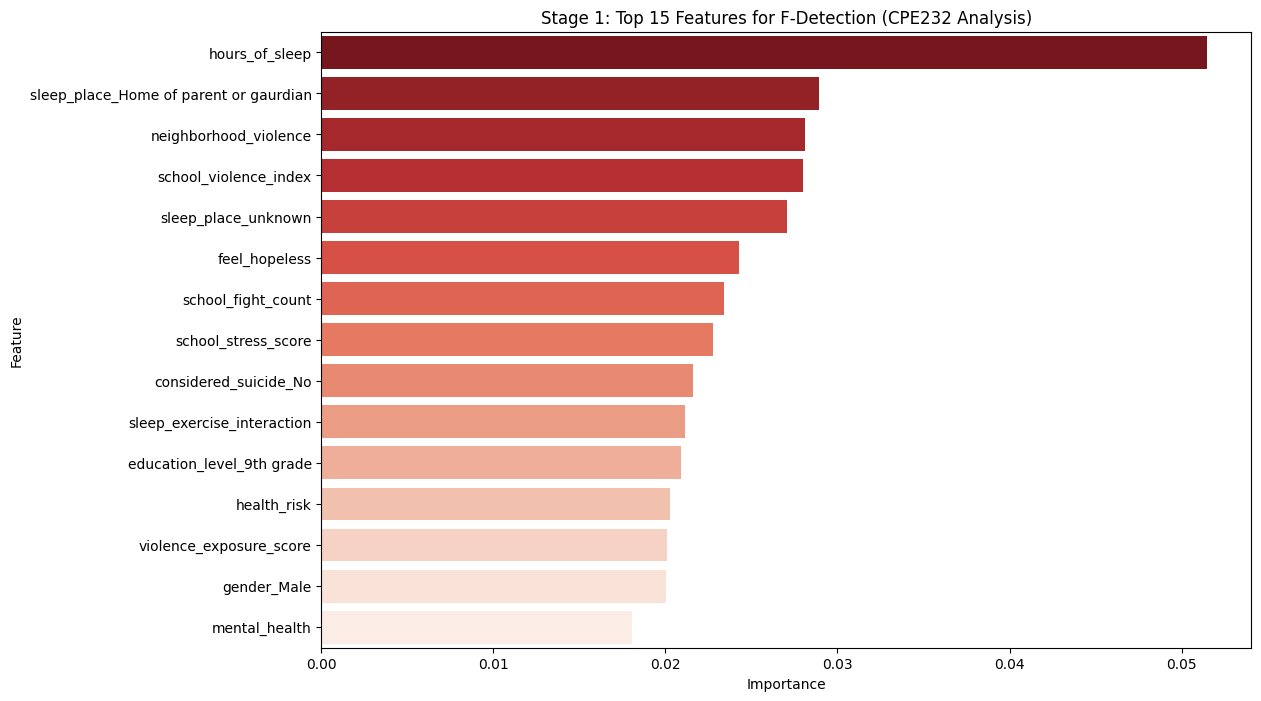

Top 10 Features for Detecting Grade F:
                                   Feature  Importance
19                          hours_of_sleep    0.051487
67  sleep_place_Home of parent or gaurdian    0.028911
6                    neighborhood_violence    0.028137
42                   school_violence_index    0.028013
73                     sleep_place_unknown    0.027074
11                           feel_hopeless    0.024290
5                       school_fight_count    0.023412
40                     school_stress_score    0.022783
63                   considered_suicide_No    0.021617
32              sleep_exercise_interaction    0.021164


In [ ]:
# Check Feature Importance for Stage 1 Model (F-Detector)

# ดึงชื่อฟีเจอร์
num_names = numeric_features 
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_names + cat_names + ['UMAP1', 'UMAP2']

# ดึงค่าน้ำหนักจากโมเดล Stage 1 (F-Detector)
importances_s1 = model_f_detector.feature_importances_

if len(all_feature_names) == len(importances_s1):
    feat_import_s1_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances_s1
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_import_s1_df.head(15), palette='Reds_r')
    plt.title('Stage 1: Top 15 Features for F-Detection (CPE232 Analysis)')
    plt.show()

    print("Top 10 Features for Detecting Grade F:")
    print(feat_import_s1_df.head(10))
else:
    print("Error: มิติของฟีเจอร์ไม่ตรงกัน")

C:\Users\Norawit\AppData\Local\Temp\ipykernel_33820\3423079576.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_import_df.head(20), palette='viridis')


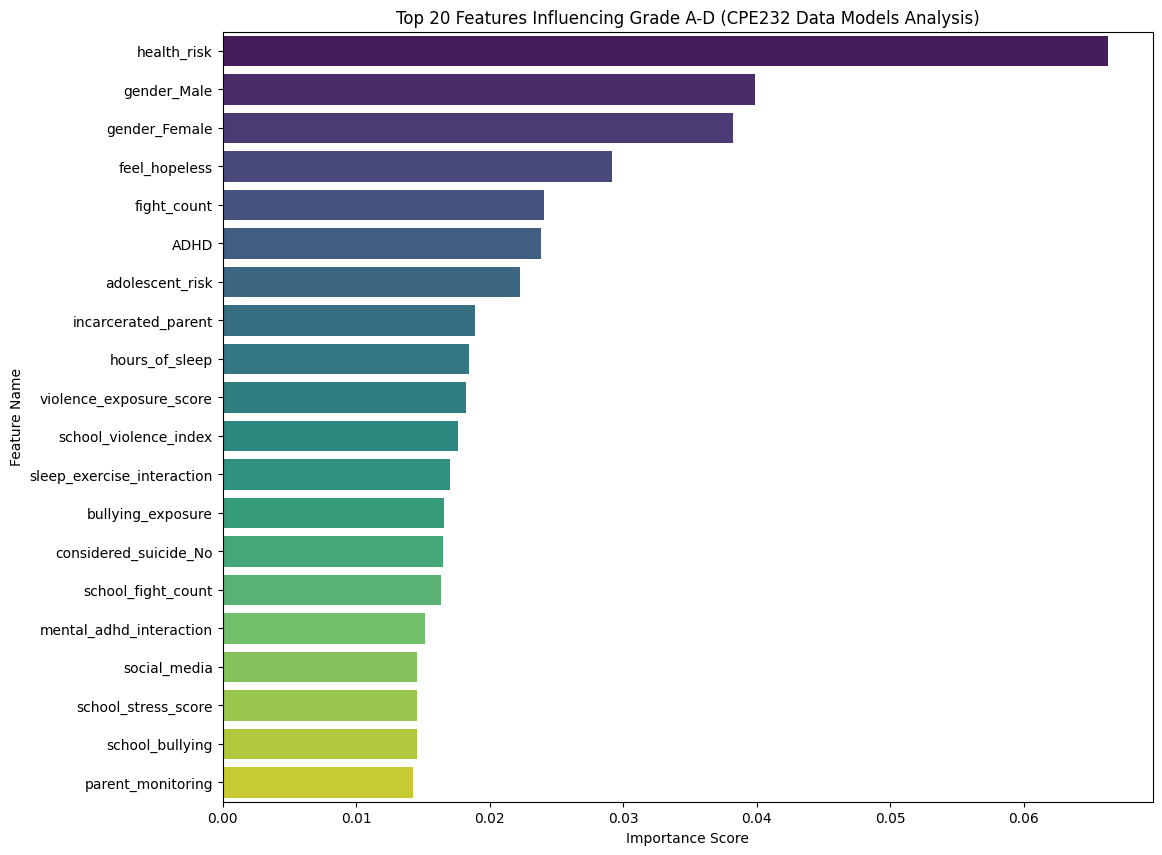

Top 10 Most Important Features:
                    Feature  Importance
31              health_risk    0.066349
55              gender_Male    0.039877
54            gender_Female    0.038196
11            feel_hopeless    0.029160
4               fight_count    0.024054
29                     ADHD    0.023879
50          adolescent_risk    0.022239
25      incarcerated_parent    0.018930
19           hours_of_sleep    0.018457
46  violence_exposure_score    0.018233


In [ ]:
# Check Feature Importance for Stage 2 Model (A-D Classification)

# ดึงรายชื่อฟีเจอร์ numeric
num_names = numeric_features 

# ดึงชื่อจากส่วน Categorical 
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()

# รวมชื่อฟีเจอร์ทั้งหมด: Numeric + One-Hot + UMAP
all_feature_names = num_names + cat_names + ['UMAP1', 'UMAP2']

# 2. ตรวจสอบจำนวนให้ตรงกับโมเดล (เพื่อป้องกัน Error เดิม)
importances = model_stage2.feature_importances_

if len(all_feature_names) == len(importances):
    # สร้าง DataFrame เพื่อจัดอันดับ
    feat_import_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 10))
    sns.barplot(x='Importance', y='Feature', data=feat_import_df.head(20), palette='viridis')
    plt.title('Top 20 Features Influencing Grade A-D (CPE232 Data Models Analysis)')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature Name')
    plt.show()

    print("Top 10 Most Important Features:")
    print(feat_import_df.head(10))
else:
    print(f"Error: จำนวนชื่อ ({len(all_feature_names)}) ไม่ตรงกับจำนวนที่โมเดลใช้ ({len(importances)})")
    print("ลองตรวจสอบการรวม X_enhanced อีกครั้งว่ามีกี่มิติ")